### **Contribution Scores - File Interrogation**

**<span style="color: darkred;">This is notebook 1/2 of the contribution score tracks downstream analyses.</span>**

Contribution scores are generated using the _ChromBPNet_pipeline/3_Data_Generation/3c_ContribsBW.sh_ script

The following script includes interrogation of the output files and identifying the automated shift by ChromBPNet of where the detected motifs are within the peaks.

All contribution score output files are available in:

_/scratch/prj/stem_cells_pituitary/Georgia/ChromBPnet/outputs/(cohort)/(name)/contribs_bw/_

In [18]:
# Libraries
import h5py 
import hdf5plugin
import pandas as pd
import logomaker
import matplotlib.pyplot as plt
import numpy as np

### <div style = 'background-color:PapayaWhip'> **Identify shift to align with motif centre**</div>

In [4]:
# Contribution Profile Scores (h5)

Lacto_pc="/scratch/prj/stem_cells_pituitary/Georgia/ChromBPnet/outputs/mouse/Lactotrophs/contribs_bw/Lactotrophs_contribs.profile_scores.h5"

with h5py.File(Lacto_pc, 'r') as file:
    # See top level
    print("Keys:", list(file.keys()))
    
    # Pick a group and see what's inside
    group_name = 'projected_shap'
    print(f"Inside {group_name}:", list(file[group_name].keys()))
    
    group_name2 = 'raw'
    print(f"Inside {group_name2}:", list(file[group_name2].keys()))

    group_name3 = 'shap'
    print(f"Inside {group_name3}:", list(file[group_name3].keys()))

Keys: ['projected_shap', 'raw', 'shap']
Inside projected_shap: ['seq']
Inside raw: ['seq']
Inside shap: ['seq']


In [5]:
# See what is further inside the keys

with h5py.File(Lacto_pc, 'r') as file:
    seq_data = file['projected_shap/seq']
    
    print(f"Shape: {seq_data.shape}")
    print(f"Datatype: {seq_data.dtype}")

Shape: (245876, 4, 2114)
Datatype: float16


**There are 245'876 genomic regions.**

**Each genomic region is represented with the 4 base pairs (A,C,T,G).**

**Each genomic region is 2114 base pairs long.**

In [7]:
# Check this number of regions matches the input regions provided

peaks_file = "/scratch/prj/stem_cells_pituitary/Georgia/ChromBPnet/data/mm10/peaks/consensus_chromatin_landscape_modified.bed.gz"

peaks = pd.read_csv(peaks_file, 
                    sep='\t', header=None, compression='gzip')

print(f"Number of regions in BED: {len(peaks)}")

Number of regions in BED: 245876


**The contribs outputs from contribs_bw get fed into the tf_modisco command.**

**This command then generates a list of top contribution sequences, names them seqlets and says how many there are.**

In [8]:
# Generate a dictionary of patterns within the tfmodisco results and their associated TF name

named_results = "/scratch/prj/stem_cells_pituitary/Georgia/ChromBPnet/outputs/mouse/Lactotrophs/tf_modisco/Lactotrophs_modisco_results_named.csv"

name_map_df = pd.read_csv(named_results)
name_dict = dict(zip(name_map_df['pattern'], name_map_df['motif0']))

#name_dict

In [10]:
modisco_h5 = "/scratch/prj/stem_cells_pituitary/Georgia/ChromBPnet/outputs/mouse/Lactotrophs/tf_modisco/modisco_results.h5"
contribs_h5 = "/scratch/prj/stem_cells_pituitary/Georgia/ChromBPnet/outputs/mouse/Lactotrophs/contribs_bw/Lactotrophs_contribs.profile_scores.h5"

with h5py.File(modisco_h5, 'r') as m_file, \
     h5py.File(contribs_h5, 'r') as c_file:
        
        # Extract the contribution score dataset
        contrib_ds = c_file['projected_shap/seq']
        # Select for positive patterns only 
        pos_patterns = m_file['pos_patterns']
        
        for p_key in pos_patterns.keys():
            # pattern_0, pattern_1, etc.
            pattern_grp = pos_patterns[p_key]
                
            lookup_key = f"pos_patterns.{p_key}"
            readable_name = name_dict.get(lookup_key, p_key)
            
            # Get seqlet indices and coordinates
            seqlets = pattern_grp['seqlets']
            indices = seqlets['example_idx'][:].astype(int)
            starts = seqlets['start'][:].astype(int)
            ends = seqlets['end'][:].astype(int)
            
            pattern_scores = []
            
            # Pull scores for every instance of this motif
            for idx, s, e in zip(indices, starts, ends):
                # Pull the specific sequence window (shape: 4, 2114)
                region_data = contrib_ds[idx] 

In [11]:
with h5py.File(modisco_h5, 'r') as m_file, h5py.File(contribs_h5, 'r') as c_file:
    
    # Access the groups
    pos_patterns = m_file['pos_patterns']
    contrib_ds = c_file['projected_shap/seq']
    
    # Pick the first pattern (first key for an example
    p_key = list(pos_patterns.keys())[1]
    pattern_grp = pos_patterns[p_key]
    
    # Get the seqlet's coordinates from that pattern
    seqlets = pattern_grp['seqlets']
    idx = int(seqlets['example_idx'][1])
    s = int(seqlets['start'][1])
    e = int(seqlets['end'][1])

Visualizing Pattern: pattern_1
Region Index: 16438 | Coordinates: 286:316


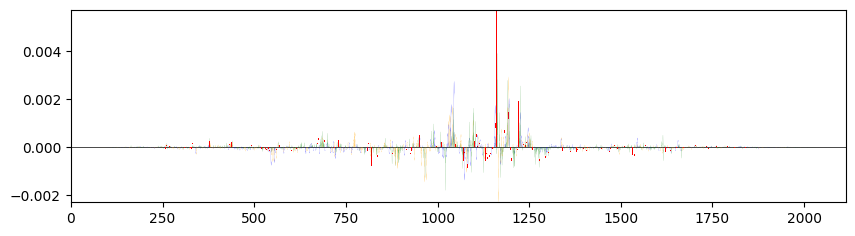

In [16]:
# Look at the total 2114 region contribution scores for the first pattern selected 

motif_to_plot = region_data.T
    
print(f"Visualizing Pattern: {p_key}")
print(f"Region Index: {idx} | Coordinates: {s}:{e}")
    
df = pd.DataFrame(motif_to_plot, columns=['A', 'C', 'G', 'T'])
logomaker.Logo(df, color_scheme='classic')
plt.show()

In [20]:
# Determine the position of highest importance within the sequence region

importance_track = np.sum(region_data, axis=0)
peak_center = np.argmax(importance_track)
print(f"The highest contribution in this region is at position: {peak_center}")

The highest contribution in this region is at position: 1161


In [21]:
# Calculate the total importance across the whole 2114 bp

importance_track = np.sum(region_data, axis=0)
actual_peak_index = np.argmax(importance_track)

print(f"The region of highest contribution is around: {actual_peak_index}")
print(f"TFModisco says the seqlet starts at: {s}")

# Calculate offset between actual peak and seqlet center
offset = actual_peak_index - (s + (e-s)//2)
print(f"Offset for positive pattern_0: {offset}")

The region of highest contribution is around: 1161
TFModisco says the seqlet starts at: 286
Offset for positive pattern_0: 860


<Figure size 1000x200 with 0 Axes>

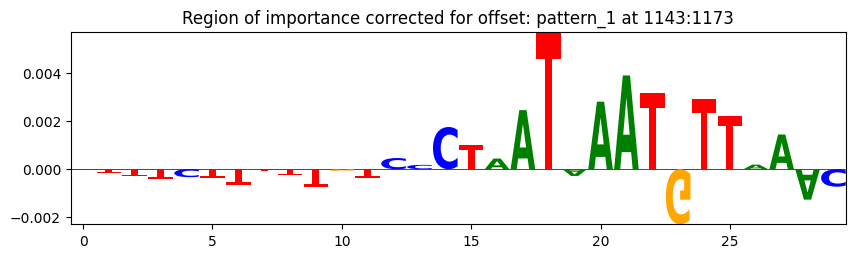

In [22]:
# Visualise contribution sequence score correcting for the estimated offset

# Assuming a 400bp window from original 2114bp region
# crop_start = ( 2114 / 2 ) - 200 
crop_start = 857

# Re-zoom into the data using the offset
true_s = s + crop_start
true_e = e + crop_start

# Extract the ACTUAL spike area
motif_data = region_data[:, true_s:true_e].T
df = pd.DataFrame(motif_data, columns=['A', 'C', 'G', 'T'])

# Plot - this will now show the actual letters of the spike!
plt.figure(figsize=(10, 2))
logomaker.Logo(df, color_scheme='classic')
plt.title(f"Region of importance corrected for offset: {p_key} at {true_s}:{true_e}")
plt.show()

**TFModisco cuts the region window to a 400bp window.**

**This means their 'start' and 'end' values are relative to the 400bp window, NOT the 2114bp region**

This offset was looked at in multiple peak regions to verify the offset is not a single occurance. 